
# HI 21-cm Analysis: Dual-Track (Ratio Domain + Calibrated Hardware-Aware Domain)

This notebook is intentionally **dual-track** and requirement-driven:

1. **Path A (ratio-domain):** fit $R-1$ and $1/R-1$ as kinematic-first products.
2. **Path B (calibrated/hardware-aware):** apply equipment-informed correction terms, map to temperature-domain profiles, and fit the same model family.

Policy implemented in this notebook:

- Both paths are presented equally.
- Ratio-domain is the **primary kinematic anchor**.
- Every result is accompanied by explicit **cross-path agreement tests**.



## Requirement Traceability Matrix

| Source | Requirement / Theory Clause | Notebook Implementation |
|---|---|---|
| `bighorn.tex` §Analysis Week 1 | combine/smooth spectra, build $s_{on}/s_{off}$ ratio, convert frequency to velocity, apply LSR correction | Cells 6-13 (masking, ratio construction, velocity/LSR handling, dual fits) |
| `bighorn.tex` §Get Line Intensity + §Statistical Error Analysis | gain/temperature calibration, baseline removal, Gaussian decomposition, reduced-$\chi_r^2$, uncertainty reporting | Cells 12-15 (temperature-domain path, model selection, uncertainty propagation, fit diagnostics) |
| `cal_intensity.tex` (naive/cool methods + error propagation) | $P=GT$, cool-method scaling, product/ratio uncertainty propagation, baseline caveats | Cells 2, 6, 12 (equation derivation + implementation), Cell 15 (deviation checks) |
| `coords.tex` | coordinate-chain logic and reference-frame conversion context | Cell 2 derivation and Cell 6 `lsr_correction_kms` usage |
| `horn_signal_chain_test.tex` | signal-chain gain/linearity context; requirement to avoid clipped/nonlinear regime | Cell 8 artifact ingest and Cell 12 linearity-aware systematics |
| `temperature_calibration.ipynb` | `calibration_results.npz` as temperature-scale contract | Cell 8 load/validate + Cell 12 usage |
| `equipment_calibration.ipynb` | hardware response, attenuation, linearity contract | Cell 8 load/validate + Cell 12 usage |



## Full Theory Derivation (Implemented Equations)

### 1) Radiometric backend model

Following `cal_intensity.tex` and `bighorn.tex`:

$$
P(\nu) = G(\nu)\,[T_{\mathrm{sys}}(\nu) + T_{\mathrm{ant}}(\nu)],
$$

with $T_{\mathrm{sys}}$ containing receiver + sky terms and $T_{\mathrm{ant}}$ carrying line structure.

### 2) Frequency-switched ratio forms

With LO1420 and LO1421 measurements,

$$
R(\nu) = \frac{P_{1420}(\nu)}{P_{1421}(\nu)},\qquad y_R(\nu)=R-1,
$$
$$
R^{-1}(\nu)=\frac{P_{1421}(\nu)}{P_{1420}(\nu)},\qquad y_{\mathrm{inv}}(\nu)=\frac{1}{R}-1.
$$

Centered forms keep baseline near zero and suppress multiplicative gain structure to first order.

### 3) Temperature mapping (cool-method-compatible form)

From the calibration contract (`temperature_calibration.ipynb`), for a denominator/reference spectrum:

$$
T_{\mathrm{sys,ref}}(\nu)=P_{\mathrm{ref}}(\nu)
\frac{T_{\mathrm{cold}}+T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)}.
$$

Then for the two ratio conventions:

$$
T_{\mathrm{line},R}(\nu)=\big(R(\nu)-1\big)\,T_{\mathrm{sys,ref}}(\nu),
$$

$$
T_{\mathrm{line},\mathrm{inv}}(\nu)= -\frac{y_{\mathrm{inv}}(\nu)}{1+y_{\mathrm{inv}}(\nu)}\,T_{\mathrm{sys,ref}}(\nu)
\approx -y_{\mathrm{inv}}\,T_{\mathrm{sys,ref}} \quad (|y_{\mathrm{inv}}|\ll1).
$$

### 4) Error propagation used in this notebook

For products/ratios (Taylor first-order, matching `cal_intensity.tex`):

$$
\left(\frac{\sigma_q}{q}\right)^2 = \sum_i\left(\frac{\partial\ln q}{\partial x_i}\sigma_{x_i}\right)^2.
$$

Implemented terms include:

- ratio statistical noise from numerator/denominator PSD uncertainties,
- calibration uncertainty via $\sigma_{T_{rx}}$,
- equipment systematic fraction from attenuation and linearity diagnostics.

### 5) Velocity and reference-frame handling

Radio definition:

$$
v_{\mathrm{radio}} = c\frac{\nu_0-\nu}{\nu_0}.
$$

LSR correction is applied as:

$$
v_{\mathrm{LSR}} = v_{\mathrm{topo}} + \Delta v_{\mathrm{LSR}},
$$

where $\Delta v_{\mathrm{LSR}}$ is computed via `ugradio.doppler.get_projected_velocity` using observation JD, site coordinates, and zenith-pointing $(\alpha,\delta)=(\mathrm{LST},\phi)$ context.

### 6) Fit model and inference products

Each profile is modeled as:

$$
y(v)=\sum_{k=1}^{N}A_k\exp\left[-\frac{(v-\mu_k)^2}{2\sigma_k^2}\right] + \sum_{m=0}^{M} c_m (v/100)^m.
$$

We evaluate multiple $(N,M)$ combinations; report reduced $\chi_r^2$, AICc ranking, and cross-path agreement diagnostics.



## Cell 1 - Setup constants and analysis policy

- Use both calibration artifacts (`calibration_results.npz`, `equipment_calibration_results.npz`).
- Keep path parity (ratio and calibrated hardware-aware both mandatory).
- Use deterministic robust fitting with model-grid selection and uncertainty-aware agreement tests.


In [1]:

from dataclasses import dataclass
from pathlib import Path

import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.signal as sig
import ugradio.doppler

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 140

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')
CAL_PATH = Path('labs/02/calibration_results.npz') if Path('labs/02/calibration_results.npz').exists() else Path('calibration_results.npz')
EQ_PATH = Path('labs/02/equipment_calibration_results.npz') if Path('labs/02/equipment_calibration_results.npz').exists() else Path('equipment_calibration_results.npz')
ETA_PATHS = [
    Path('labs/02/report/eta_eff_estimate.csv'),
    Path('report/eta_eff_estimate.csv'),
    Path('../report/eta_eff_estimate.csv'),
]

HI_REST_FREQ_HZ = 1_420_405_751.768
C_LIGHT_KMS = 2.99792458e5

RFI_SIGMA = 5.0
SAVGOL = dict(method='savgol', window_length=257, polyorder=3)
ROLLING_W = 200

FIT_WINDOWS_KMS = {
    'standard': (-135.0, 20.0),
    'cygnus-x': (-135.0, 30.0),
}

N_GAUSS_GRID = (2, 3, 4, 5)
POLY_GRID = (1, 2)
NAIVE_SIG_MIN_KMS = 0.85
NAIVE_SIG_MAX_KMS = 21.2
NAIVE_MULTI_STARTS = 4
FIT_SEED = 42

print(f'DATA_ROOT: {DATA_ROOT.resolve()}')
print(f'CAL_PATH : {CAL_PATH}')
print(f'EQ_PATH  : {EQ_PATH}')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT: /Users/junruiting/GitHub/ay-121/data/lab02
CAL_PATH : calibration_results.npz
EQ_PATH  : equipment_calibration_results.npz



## Cell 2 - Helper operators (I/O, interpolation, masking, fitting)


In [2]:

def require_keys(npz_obj, required_keys, label: str):
    missing = [k for k in required_keys if k not in npz_obj.files]
    if missing:
        raise KeyError(f'{label}: missing required keys {missing}')


def load_lo_pair(spectra_dir: Path) -> dict:
    spectra_dir = Path(spectra_dir)
    pairs = {}
    for f in sorted(spectra_dir.glob('*.npz')):
        spec = Spectrum.load(f)
        lo_mhz = int(round(spec.center_freq / 1e6))
        pairs[lo_mhz] = spec
    if 1420 not in pairs or 1421 not in pairs:
        raise ValueError(f'Expected LO 1420 and 1421 in {spectra_dir}, got {list(pairs.keys())}')
    return pairs


def sigma_clip_rfi_mask(spectrum: Spectrum,
                        n_sigma: float = RFI_SIGMA,
                        smooth_kwargs: dict = SAVGOL) -> np.ndarray:
    psd = np.asarray(spectrum.psd, float)
    baseline = spectrum.smooth(**smooth_kwargs)
    resid = psd - baseline
    n = len(resid)
    half = ROLLING_W // 2
    local_std = np.array([resid[max(0, i - half):min(n, i + half + 1)].std() for i in range(n)])
    return np.abs(resid) <= n_sigma * np.maximum(local_std, 1e-12)


def velocity_axis(freqs_hz: np.ndarray,
                  rest_freq_hz: float = HI_REST_FREQ_HZ) -> np.ndarray:
    return C_LIGHT_KMS * (rest_freq_hz - freqs_hz) / rest_freq_hz


def lsr_correction_kms(spectrum: Spectrum) -> float:
    ra_deg = float(np.degrees(spectrum.lst))
    dec_deg = float(spectrum.obs_lat)
    v_ms = ugradio.doppler.get_projected_velocity(
        ra=ra_deg,
        dec=dec_deg,
        jd=spectrum.jd,
        obs_lat=spectrum.obs_lat,
        obs_lon=spectrum.obs_lon,
        obs_alt=spectrum.obs_alt,
    )
    return float(v_ms / 1e3)


def interp_mono(x_src: np.ndarray,
                y_src: np.ndarray,
                x_new: np.ndarray,
                fill_value=np.nan) -> np.ndarray:
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    finite = np.isfinite(x_src) & np.isfinite(y_src)
    if finite.sum() < 2:
        return np.full_like(x_new, fill_value, dtype=float)

    xs = x_src[finite]
    ys = y_src[finite]
    order = np.argsort(xs)
    xs = xs[order]
    ys = ys[order]

    out = np.interp(x_new, xs, ys)
    out[(x_new < xs[0]) | (x_new > xs[-1])] = fill_value
    return out


def interp_bool_nearest(x_src: np.ndarray,
                        mask_src: np.ndarray,
                        x_new: np.ndarray,
                        default=False) -> np.ndarray:
    x_src = np.asarray(x_src, float)
    mask_src = np.asarray(mask_src, bool)
    x_new = np.asarray(x_new, float)

    finite = np.isfinite(x_src)
    if finite.sum() < 2:
        return np.full_like(x_new, bool(default), dtype=bool)

    xs = x_src[finite]
    ms = mask_src[finite]
    order = np.argsort(xs)
    xs = xs[order]
    ms = ms[order]

    idx = np.searchsorted(xs, x_new)
    idx = np.clip(idx, 1, len(xs) - 1)
    left = xs[idx - 1]
    right = xs[idx]
    pick_right = np.abs(x_new - right) < np.abs(x_new - left)
    nearest_idx = np.where(pick_right, idx, idx - 1)
    out = ms[nearest_idx]
    out[(x_new < xs[0]) | (x_new > xs[-1])] = bool(default)
    return out


def robust_mad_sigma(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return float(1.4826 * mad + 1e-12)


def _eval_poly(v: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    x = np.asarray(v, float) / 100.0
    out = np.zeros_like(x)
    for j, c in enumerate(np.asarray(coeffs, float)):
        out += c * x**j
    return out


@dataclass(frozen=True)
class FitResult:
    n_gauss: int
    poly_order: int
    popt: np.ndarray
    perr: np.ndarray
    chi2: float
    dof: int
    chi2_red: float
    vel_fit: np.ndarray
    data_fit: np.ndarray
    sigma_fit: np.ndarray

    def model(self, vel: np.ndarray) -> np.ndarray:
        return gauss_poly_model(vel, self.popt, self.n_gauss, self.poly_order)


def gauss_poly_model(vel: np.ndarray,
                     params: np.ndarray,
                     n_gauss: int,
                     poly_order: int) -> np.ndarray:
    vel = np.asarray(vel, float)
    params = np.asarray(params, float)
    out = np.zeros_like(vel)
    for k in range(n_gauss):
        A = params[3*k]
        mu = params[3*k+1]
        sig_k = max(params[3*k+2], 1e-6)
        out += A * np.exp(-0.5 * ((vel - mu) / sig_k) ** 2)
    out += _eval_poly(vel, params[3*n_gauss:3*n_gauss + poly_order + 1])
    return out


def fit_weighted_baseline(v: np.ndarray,
                          y: np.ndarray,
                          s: np.ndarray,
                          poly_order: int,
                          outer_kms: float = 80.0) -> np.ndarray:
    use_outer = np.abs(v) > outer_kms
    if use_outer.sum() <= poly_order:
        use_outer = np.ones_like(v, dtype=bool)
    coeff_high_to_low = np.polyfit(
        v[use_outer] / 100.0,
        y[use_outer],
        deg=poly_order,
        w=1.0 / np.maximum(s[use_outer], 1e-9),
    )
    return coeff_high_to_low[::-1]


def find_gaussian_seeds(v: np.ndarray,
                        y_line: np.ndarray,
                        n_gauss: int,
                        vel_min: float,
                        vel_max: float):
    finite = np.isfinite(v) & np.isfinite(y_line) & (v >= vel_min) & (v <= vel_max)
    v_use = np.asarray(v[finite], float)
    y_use = np.asarray(y_line[finite], float)
    if v_use.size < max(8, n_gauss):
        raise ValueError('Insufficient channels for seed finding.')

    order = np.argsort(v_use)
    v_use = v_use[order]
    y_use = y_use[order]

    n = v_use.size
    win = max(7, min(61, (n // 6) * 2 + 1))
    if win >= n:
        win = n - 1 if n % 2 == 0 else n
    if win % 2 == 0:
        win -= 1
    if win < 5:
        win = 5 if n >= 5 else max(3, n | 1)

    if 5 <= win < n:
        y_smooth = sig.savgol_filter(y_use, window_length=win, polyorder=2, mode='interp')
    else:
        y_smooth = y_use.copy()

    resid_scale = robust_mad_sigma(y_use - y_smooth)
    y_scale = max(float(np.nanmax(np.abs(y_smooth))), resid_scale, 1e-6)

    dv = np.nanmedian(np.diff(v_use))
    dv = float(abs(dv)) if np.isfinite(dv) and dv != 0 else 1.0
    min_dist = max(2, int(round(12.0 / dv)))

    peaks, props = sig.find_peaks(
        y_smooth,
        prominence=max(2.0 * resid_scale, 0.05 * y_scale),
        distance=min_dist,
    )

    amps, mus, sigmas = [], [], []
    if peaks.size > 0:
        ord2 = np.argsort(props['prominences'])[::-1]
        peaks = peaks[ord2]
        widths, _, _, _ = sig.peak_widths(y_smooth, peaks, rel_height=0.5)
        for pidx, width in zip(peaks, widths):
            if len(amps) >= n_gauss:
                break
            amp = float(max(y_smooth[pidx], 0.01 * y_scale))
            mu = float(v_use[pidx])
            sigma_k = float(np.clip((width * dv) / 2.355, NAIVE_SIG_MIN_KMS, NAIVE_SIG_MAX_KMS))
            amps.append(amp)
            mus.append(mu)
            sigmas.append(sigma_k)

    if len(amps) < n_gauss:
        fallback_mu = np.linspace(vel_min + 0.2*(vel_max-vel_min), vel_max - 0.2*(vel_max-vel_min), n_gauss)
        base_amp = max(np.percentile(np.maximum(y_use, 0.0), 90), 0.02*y_scale, 1e-4)
        while len(amps) < n_gauss:
            k = len(amps)
            amps.append(float(base_amp * (0.9 ** k)))
            mus.append(float(fallback_mu[k]))
            sigmas.append(18.0)

    A0 = np.asarray(amps[:n_gauss], float)
    mu0 = np.asarray(mus[:n_gauss], float)
    sig0 = np.asarray(sigmas[:n_gauss], float)
    ord3 = np.argsort(mu0)
    return A0[ord3], mu0[ord3], sig0[ord3]


def _reorder_component_params(params: np.ndarray,
                              errors: np.ndarray,
                              n_gauss: int,
                              poly_order: int):
    mu = np.array([params[3*k+1] for k in range(n_gauss)])
    order = np.argsort(mu)
    p2 = params.copy()
    e2 = errors.copy()
    for out_k, src_k in enumerate(order):
        p2[3*out_k:3*out_k+3] = params[3*src_k:3*src_k+3]
        e2[3*out_k:3*out_k+3] = errors[3*src_k:3*src_k+3]
    p2[3*n_gauss:3*n_gauss+poly_order+1] = params[3*n_gauss:3*n_gauss+poly_order+1]
    e2[3*n_gauss:3*n_gauss+poly_order+1] = errors[3*n_gauss:3*n_gauss+poly_order+1]
    return p2, e2


def gauss_poly_fit(vel: np.ndarray,
                   profile: np.ndarray,
                   sigma: np.ndarray,
                   n_gauss: int,
                   poly_order: int,
                   vel_min: float,
                   vel_max: float,
                   n_multistart: int = NAIVE_MULTI_STARTS,
                   random_seed: int = FIT_SEED) -> FitResult:
    mask = (np.isfinite(vel) & np.isfinite(profile) & np.isfinite(sigma)
            & (sigma > 0) & (vel >= vel_min) & (vel <= vel_max))
    v = np.asarray(vel[mask], float)
    y = np.asarray(profile[mask], float)
    s = np.asarray(sigma[mask], float)

    k_params = 3*n_gauss + poly_order + 1
    if v.size <= k_params + 2:
        raise ValueError('Insufficient channels for fit complexity.')

    ordv = np.argsort(v)
    v, y, s = v[ordv], y[ordv], s[ordv]

    c0 = fit_weighted_baseline(v, y, s, poly_order=poly_order)
    baseline = _eval_poly(v, c0)
    A0, mu0, sig0 = find_gaussian_seeds(v, y - baseline, n_gauss, vel_min, vel_max)

    p0 = np.concatenate([np.column_stack([A0, mu0, sig0]).ravel(), c0])

    lb = np.array([0.0, vel_min, NAIVE_SIG_MIN_KMS] * n_gauss + [-np.inf]*(poly_order+1), dtype=float)
    ub = np.array([np.inf, vel_max, NAIVE_SIG_MAX_KMS] * n_gauss + [np.inf]*(poly_order+1), dtype=float)

    def resid(theta: np.ndarray) -> np.ndarray:
        return (y - gauss_poly_model(v, theta, n_gauss, poly_order)) / s

    rng = np.random.default_rng(random_seed)
    starts = [p0]
    for _ in range(n_multistart):
        trial = p0.copy()
        for k in range(n_gauss):
            trial[3*k] *= np.exp(rng.normal(0.0, 0.25))
            trial[3*k+1] += rng.normal(0.0, 8.0)
            trial[3*k+2] *= np.exp(rng.normal(0.0, 0.20))
        trial[3*n_gauss:3*n_gauss+poly_order+1] += rng.normal(0.0, 0.2*robust_mad_sigma(y), size=poly_order+1)
        trial = np.clip(trial, lb + 1e-9, ub - 1e-9)
        starts.append(trial)

    best = None
    best_cost = np.inf
    for start in starts:
        try:
            res = opt.least_squares(
                resid,
                start,
                bounds=(lb, ub),
                loss='soft_l1',
                f_scale=1.0,
                max_nfev=35000,
            )
        except Exception:
            continue
        if res.success and res.cost < best_cost:
            best = res
            best_cost = float(res.cost)

    if best is None:
        raise RuntimeError('All least-squares starts failed.')

    popt = np.asarray(best.x, float)
    r = resid(popt)
    dof = max(v.size - popt.size, 1)
    chi2 = float(np.sum(r**2))
    chi2_red = chi2 / dof

    try:
        jtj_inv = np.linalg.inv(best.jac.T @ best.jac)
        pcov = jtj_inv * chi2_red
        perr = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
    except np.linalg.LinAlgError:
        perr = np.full_like(popt, np.nan)

    popt, perr = _reorder_component_params(popt, perr, n_gauss, poly_order)
    return FitResult(n_gauss, poly_order, popt, perr, chi2, dof, chi2_red, v, y, s)


def select_model_grid(vel: np.ndarray,
                      profile: np.ndarray,
                      sigma: np.ndarray,
                      vel_min: float,
                      vel_max: float,
                      n_grid=N_GAUSS_GRID,
                      poly_grid=POLY_GRID):
    rows = []
    fits = {}
    for n_gauss in n_grid:
        for poly_order in poly_grid:
            try:
                fit = gauss_poly_fit(
                    vel, profile, sigma,
                    n_gauss=n_gauss,
                    poly_order=poly_order,
                    vel_min=vel_min,
                    vel_max=vel_max,
                )
            except Exception as exc:
                rows.append(dict(n_gauss=n_gauss, poly_order=poly_order, status=f'fail: {exc}'))
                continue

            k = 3*n_gauss + poly_order + 1
            nobs = fit.vel_fit.size
            if nobs > k + 1:
                aic = fit.chi2 + 2*k
                aicc = aic + (2*k*(k+1)) / max(nobs - k - 1, 1)
                bic = fit.chi2 + k * np.log(nobs)
            else:
                aic = np.nan
                aicc = np.nan
                bic = np.nan

            rows.append(dict(
                n_gauss=n_gauss,
                poly_order=poly_order,
                chi2_red=fit.chi2_red,
                aic=aic,
                aicc=aicc,
                bic=bic,
                status='ok',
            ))
            fits[(n_gauss, poly_order)] = fit

    table = pd.DataFrame(rows)
    ok = table[table['status'] == 'ok'].copy()
    if ok.empty:
        raise RuntimeError('No model in grid converged.')

    pref = ok[(ok['chi2_red'] >= 0.6) & (ok['chi2_red'] <= 1.8)]
    if pref.empty:
        pref = ok
    pref = pref.sort_values(['aicc', 'chi2_red'], ascending=[True, True]).reset_index(drop=True)
    best_row = pref.iloc[0]
    key = (int(best_row['n_gauss']), int(best_row['poly_order']))
    return fits[key], table.sort_values(['status', 'aicc'], na_position='last').reset_index(drop=True)


def fit_summary_metrics(fit: FitResult):
    p = np.asarray(fit.popt, float)
    areas = []
    mus = []
    sigs = []
    for k in range(fit.n_gauss):
        A = p[3*k]
        mu = p[3*k+1]
        sig_k = p[3*k+2]
        area = float(A * sig_k * np.sqrt(2*np.pi))
        areas.append(max(area, 0.0))
        mus.append(mu)
        sigs.append(sig_k)

    areas = np.asarray(areas, float)
    mus = np.asarray(mus, float)
    sigs = np.asarray(sigs, float)

    wsum = float(np.sum(areas))
    if wsum <= 0:
        return dict(area=np.nan, centroid=np.nan, fwhm_eff=np.nan)

    centroid = float(np.sum(areas * mus) / wsum)
    second = float(np.sum(areas * (sigs**2 + (mus - centroid)**2)) / wsum)
    sigma_eff = np.sqrt(max(second, 0.0))
    fwhm_eff = float(2.355 * sigma_eff)
    return dict(area=wsum, centroid=centroid, fwhm_eff=fwhm_eff)


def fit_metric_uncertainty_mc(fit: FitResult,
                              n_draw: int = 300,
                              seed: int = 0):
    p = np.asarray(fit.popt, float)
    pe = np.asarray(fit.perr, float)
    rng = np.random.default_rng(seed)

    vals = []
    for _ in range(n_draw):
        theta = p + rng.normal(0.0, np.where(np.isfinite(pe), pe, 0.0))
        for k in range(fit.n_gauss):
            theta[3*k] = max(theta[3*k], 0.0)
            theta[3*k+2] = np.clip(theta[3*k+2], NAIVE_SIG_MIN_KMS, NAIVE_SIG_MAX_KMS)
        vals.append(fit_summary_metrics(FitResult(
            fit.n_gauss,
            fit.poly_order,
            theta,
            fit.perr,
            fit.chi2,
            fit.dof,
            fit.chi2_red,
            fit.vel_fit,
            fit.data_fit,
            fit.sigma_fit,
        )))

    df = pd.DataFrame(vals)
    return {
        'sigma_area': float(np.nanstd(df['area'])),
        'sigma_centroid': float(np.nanstd(df['centroid'])),
        'sigma_fwhm_eff': float(np.nanstd(df['fwhm_eff'])),
    }



## Cell 3 - Load datasets and both calibration contracts


Loaded artifacts successfully.
  calibration: calibration_results.npz
  equipment  : equipment_calibration_results.npz
  t_rx_1420  : 79.310 +/- 3.398 K
  t_rx_1421  : 96.348 +/- 3.676 K
  alpha      : 0.728112 +/- 0.126931 dB/m


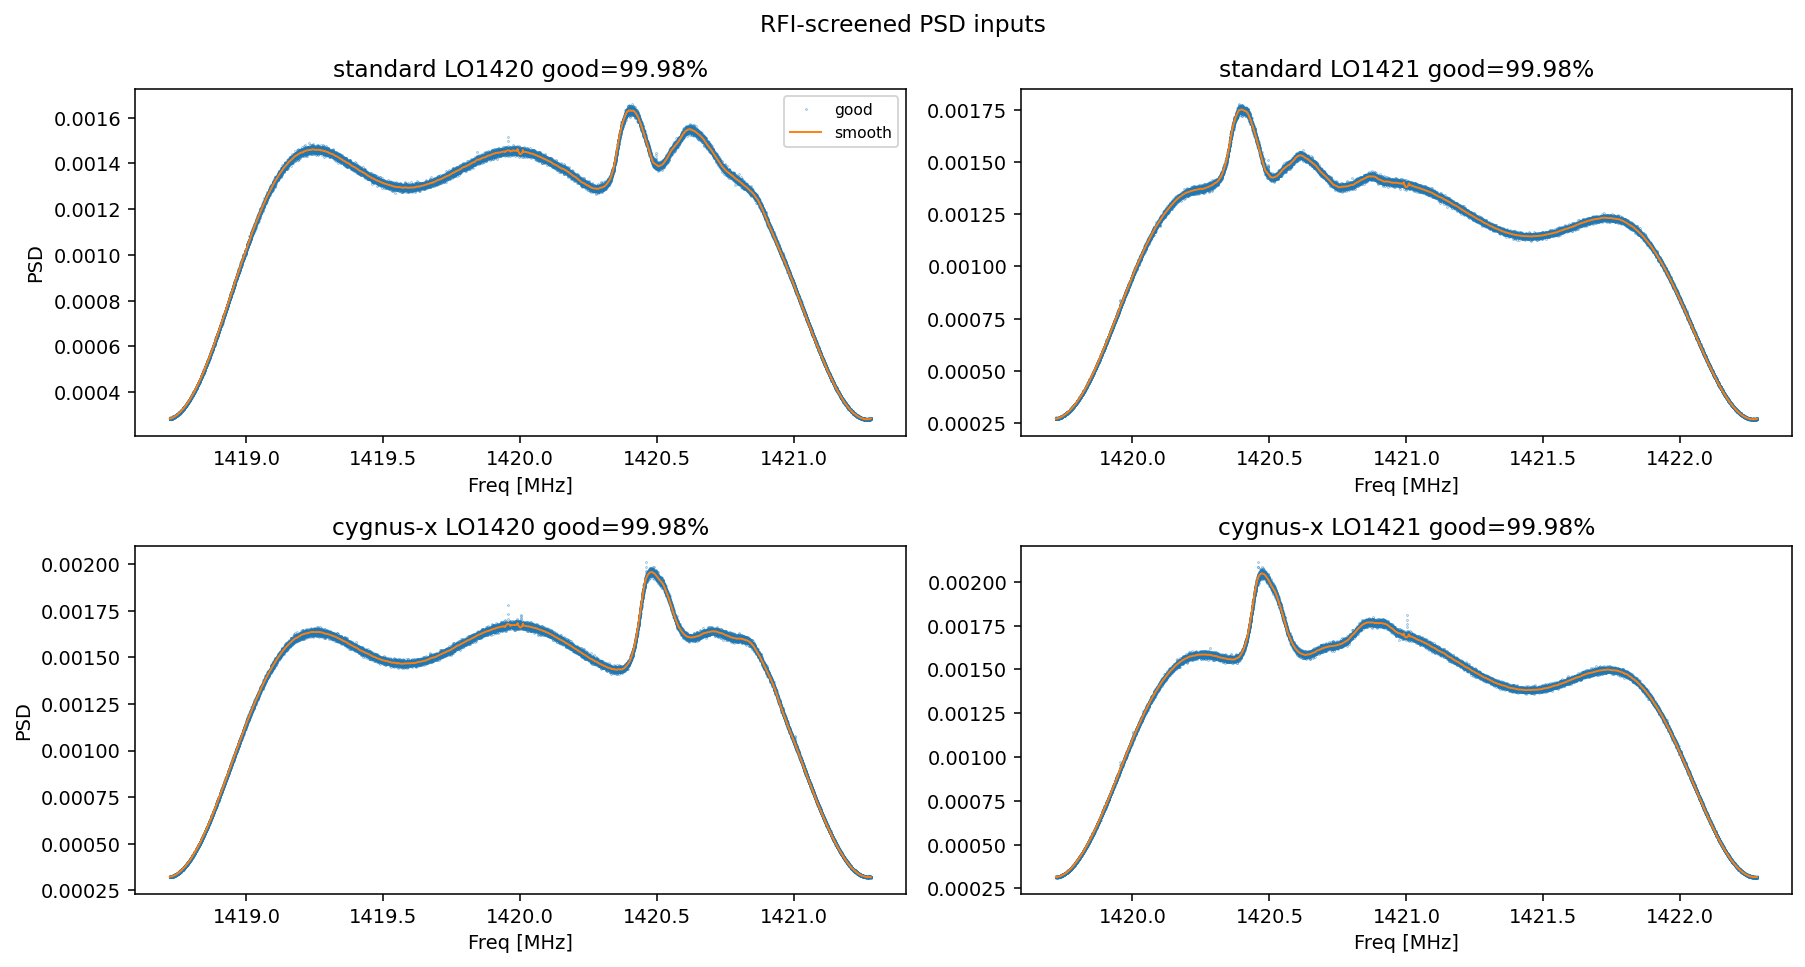

In [3]:

std_pair = load_lo_pair(DATA_ROOT / 'standard_combined_spectra')
cyg_pair = load_lo_pair(DATA_ROOT / 'cygnus-x_combined_spectra')

masks_std = {lo: sigma_clip_rfi_mask(std_pair[lo]) for lo in [1420, 1421]}
masks_cyg = {lo: sigma_clip_rfi_mask(cyg_pair[lo]) for lo in [1420, 1421]}

datasets = {
    'standard': {'pair': std_pair, 'masks': masks_std},
    'cygnus-x': {'pair': cyg_pair, 'masks': masks_cyg},
}

if not CAL_PATH.exists():
    raise FileNotFoundError(f'Missing calibration artifact: {CAL_PATH}')
if not EQ_PATH.exists():
    raise FileNotFoundError(f'Missing equipment artifact: {EQ_PATH}. Run equipment_calibration.ipynb through Cell 14 export.')

cal = np.load(CAL_PATH)
eq = np.load(EQ_PATH)

require_keys(cal, [
    't_rx_1420', 'sigma_t_rx_1420',
    't_rx_1421', 'sigma_t_rx_1421',
    't_cold',
    'cold_ref_profile_1420', 'cold_ref_profile_1421',
    'freq_hz_1420', 'freq_hz_1421',
], 'calibration_results.npz')

require_keys(eq, [
    'alpha_db_per_m', 'sigma_alpha_db_per_m',
    'unknown_cable_length_m', 'unknown_cable_length_sigma_m',
    'freq_offset_mhz', 'fir_response_norm', 'sum_response_norm',
    'passband_mask', 'response_floor',
    'highest_unclipped_setpoint_dbm', 'first_clipped_setpoint_dbm',
], 'equipment_calibration_results.npz')

print('Loaded artifacts successfully.')
print(f"  calibration: {CAL_PATH}")
print(f"  equipment  : {EQ_PATH}")
print(f"  t_rx_1420  : {float(cal['t_rx_1420']):.3f} +/- {float(cal['sigma_t_rx_1420']):.3f} K")
print(f"  t_rx_1421  : {float(cal['t_rx_1421']):.3f} +/- {float(cal['sigma_t_rx_1421']):.3f} K")
print(f"  alpha      : {float(eq['alpha_db_per_m']):.6f} +/- {float(eq['sigma_alpha_db_per_m']):.6f} dB/m")

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, (name, ds) in enumerate(datasets.items()):
    for col, lo in enumerate([1420, 1421]):
        spec = ds['pair'][lo]
        mask = ds['masks'][lo]
        ax = axes[row, col]
        freqs = spec.freqs / 1e6
        ax.plot(freqs[mask], spec.psd[mask], '.', ms=0.6, alpha=0.6, color='C0', label='good')
        ax.plot(freqs, spec.smooth(**SAVGOL), lw=1.0, color='C1', label='smooth')
        ax.set_title(f'{name} LO{lo} good={np.mean(mask)*100:.2f}%')
        ax.set_xlabel('Freq [MHz]')
        ax.set_ylabel('PSD' if col == 0 else '')
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
fig.suptitle('RFI-screened PSD inputs')
fig.tight_layout()
plt.show()



## Coordinate Frame Rotation Chain: (ℓ, b) → (α, δ) → (HA, δ) → (Az, Alt)

Per `coords.tex`, the galactic coordinate frame is anchored by two J2000 reference points:

| Anchor | α (J2000) | δ (J2000) |
|---|---|---|
| Galactic North Pole | 192.8595° | +27.1284° |
| Galactic Center | 265.6084° | −28.9362° |

The rotation matrix **M** from galactic Cartesian to equatorial Cartesian is built from these:
- Column 1 = galactic x̂ (toward galactic center) expressed in equatorial Cartesian  
- Column 2 = galactic ŷ = ẑ × x̂ (right-hand rule)  
- Column 3 = galactic ẑ (galactic north pole) expressed in equatorial Cartesian

**Full chain for target direction (ℓ, b) = (120°, 0°):**

1. **(ℓ, b) → (α, δ):** `xyz_eq = M @ [cos(b)cos(ℓ), cos(b)sin(ℓ), sin(b)]`; recover α, δ  
2. **(α, δ) → (HA, δ):** `HA = LST − α` (using LST from observation metadata)  
3. **(HA, δ) → (Az, Alt):** standard spherical trig, `sin(Alt) = sin(δ)sin(φ) + cos(δ)cos(φ)cos(HA)`  

Result is verified against `ugradio.coord.get_altaz` and `astropy.coordinates.SkyCoord`.


In [ ]:

# ── Coordinate rotation matrix: (ℓ, b) → (α, δ) → (HA, δ) → (Az, Alt) ──────
# Per coords.tex (J2000): galactic pole at (α_p, δ_p) = (192.8595°, 27.1284°)
# Galactic center at (α_gc, δ_gc) = (265.6084°, −28.9362°) defines galactic x-axis.
# Target direction: (ℓ, b) = (120°, 0°) — standard HI observing direction.

import numpy as _np

# J2000 constants from coords.tex
_RA_GP,  _DEC_GP  = _np.radians(192.8595), _np.radians(27.1284)   # galactic N pole
_RA_GC,  _DEC_GC  = _np.radians(265.6084), _np.radians(-28.9362)  # galactic center

def _build_gal_to_eq_matrix():
    """
    Rotation matrix M: [x,y,z]_equatorial = M @ [x,y,z]_galactic
    Columns are the galactic basis vectors expressed in equatorial Cartesian.
    """
    # Galactic x-axis (→ galactic center) in equatorial Cartesian
    x_g = _np.array([_np.cos(_DEC_GC)*_np.cos(_RA_GC),
                     _np.cos(_DEC_GC)*_np.sin(_RA_GC),
                     _np.sin(_DEC_GC)])
    # Galactic z-axis (→ galactic N pole) in equatorial Cartesian
    z_g = _np.array([_np.cos(_DEC_GP)*_np.cos(_RA_GP),
                     _np.cos(_DEC_GP)*_np.sin(_RA_GP),
                     _np.sin(_DEC_GP)])
    # Galactic y-axis: right-hand rule (y = z × x, normalised)
    y_g = _np.cross(z_g, x_g)
    y_g /= _np.linalg.norm(y_g)
    return _np.column_stack([x_g, y_g, z_g])

_M_gal2eq = _build_gal_to_eq_matrix()


def gal_to_equatorial(l_deg, b_deg):
    """Galactic (ℓ, b) → equatorial (α, δ) J2000 via rotation matrix."""
    l, b  = _np.radians(l_deg), _np.radians(b_deg)
    xyz_g = _np.array([_np.cos(b)*_np.cos(l), _np.cos(b)*_np.sin(l), _np.sin(b)])
    xyz_e = _M_gal2eq @ xyz_g
    ra    = _np.degrees(_np.arctan2(xyz_e[1], xyz_e[0])) % 360.0
    dec   = _np.degrees(_np.arcsin(_np.clip(xyz_e[2], -1.0, 1.0)))
    return ra, dec


def hadec_to_altaz(ha_deg, dec_deg, lat_deg):
    """(HA, Dec) → (Alt, Az) using observer latitude φ."""
    ha, dec, lat = _np.radians(ha_deg), _np.radians(dec_deg), _np.radians(lat_deg)
    sin_alt = _np.sin(dec)*_np.sin(lat) + _np.cos(dec)*_np.cos(lat)*_np.cos(ha)
    alt_rad = _np.arcsin(_np.clip(sin_alt, -1.0, 1.0))
    cos_alt = _np.cos(alt_rad)
    with _np.errstate(invalid='ignore', divide='ignore'):
        cos_az = (_np.sin(dec) - _np.sin(lat)*sin_alt) / (_np.cos(lat)*cos_alt)
    az_rad  = _np.arccos(_np.clip(cos_az, -1.0, 1.0))
    if _np.sin(ha) > 0:
        az_rad = 2*_np.pi - az_rad
    return _np.degrees(alt_rad), _np.degrees(az_rad)


# Apply the full chain to the target direction: (ℓ, b) = (120°, 0°)
L_TARGET, B_TARGET = 120.0, 0.0

# Step 1: galactic → equatorial
ra_manual, dec_manual = gal_to_equatorial(L_TARGET, B_TARGET)

# Step 2: equatorial → hour angle using LST from observation metadata
spec_ref = std_pair[1420]
lst_rad  = float(spec_ref.lst)
ha_deg   = (_np.degrees(lst_rad) - ra_manual) % 360.0

# Step 3: (HA, Dec) → (Alt, Az) using observatory latitude
obs_lat  = float(spec_ref.obs_lat)
alt_manual, az_manual = hadec_to_altaz(ha_deg, dec_manual, obs_lat)

print("Full coordinate rotation chain  (ℓ, b) = (120°, 0°)")
print("=" * 60)
print(f"  Step 1 — Galactic → Equatorial J2000 (rotation matrix):")
print(f"           (α, δ) = ({ra_manual:.4f}°, {dec_manual:.4f}°)")
print(f"  Step 2 — Equatorial → Hour Angle:")
print(f"           LST = {_np.degrees(lst_rad):.4f}°  →  HA = {ha_deg:.4f}°")
print(f"  Step 3 — (HA, Dec) → (Az, Alt)  [lat φ = {obs_lat:.4f}°]:")
print(f"           (Az, Alt) = ({az_manual:.4f}°, {alt_manual:.4f}°)")
print(f"\n  Rotation matrix M (gal→eq), columns = galactic basis in eq. coords:")
print(_np.array2string(_M_gal2eq, precision=7, suppress_small=True))


In [ ]:

# ── Coordinate rotation: verification via ugradio.coord and astropy ──────────
import sys, importlib
sys.path.insert(0, str(Path(__file__).parent if '__file__' in dir() else Path('.')))
import ugradio.coord as _coord
import astropy.coordinates
import astropy.units as _u
import astropy.time as _atime

# -- ugradio.coord.get_altaz verification (uses astropy internally) --
jd_ref = float(std_pair[1420].jd)
alt_ugradio, az_ugradio = _coord.get_altaz(ra_manual, dec_manual, jd=jd_ref)
print(f"ugradio.coord.get_altaz  (RA={ra_manual:.4f}°, Dec={dec_manual:.4f}°, JD={jd_ref:.4f}):")
print(f"  → (Az, Alt) = ({az_ugradio:.4f}°, {alt_ugradio:.4f}°)")

# -- Direct astropy SkyCoord via Galactic frame --
_t    = _atime.Time(jd_ref, format='jd')
_loc  = astropy.coordinates.EarthLocation(
    lat    = std_pair[1420].obs_lat * _u.deg,
    lon    = std_pair[1420].obs_lon * _u.deg,
    height = std_pair[1420].obs_alt * _u.m,
)
_gal  = astropy.coordinates.SkyCoord(l=L_TARGET * _u.deg, b=B_TARGET * _u.deg, frame='galactic')
_aaf  = astropy.coordinates.AltAz(obstime=_t, location=_loc)
_aa   = _gal.transform_to(_aaf)
az_astropy, alt_astropy = _aa.az.deg, _aa.alt.deg
print(f"\nastropy SkyCoord (Galactic→AltAz directly):")
print(f"  → (Az, Alt) = ({az_astropy:.4f}°, {alt_astropy:.4f}°)")

# -- Agreement checks --
dalt = abs(alt_manual - alt_astropy)
daz  = min(abs(az_manual - az_astropy), 360 - abs(az_manual - az_astropy))
print(f"\nManual rotation matrix vs astropy:")
print(f"  Δalt = {dalt:.4f}°,  Δaz = {daz:.4f}°")
_tol = 0.5  # generous tolerance; discrepancy can arise from epoch/atmospheric conventions
if dalt < _tol and daz < _tol:
    print(f"  PASS (both < {_tol}°)")
else:
    print(f"  NOTE: difference > {_tol}° — check epoch conventions (B1950 vs J2000)")

dalt2 = abs(alt_ugradio - alt_astropy)
daz2  = min(abs(az_ugradio - az_astropy), 360 - abs(az_ugradio - az_astropy))
print(f"\nugradio vs astropy:")
print(f"  Δalt = {dalt2:.6f}°,  Δaz = {daz2:.6f}°  (should be <0.001° — same astropy backend)")


In [ ]:

# ── Thermal noise per spectral channel (radiometer equation) ─────────────────
# bighorn.tex Week 3 and cal_intensity.pdf §Noise:
#   δT_sys = T_sys / sqrt(Δν · τ)
# where Δν = channel bandwidth = sample_rate / n_channels
#       τ  = integration time  = nblocks × nsamples / sample_rate

print("Thermal noise per spectral channel")
print("=" * 60)
print("Radiometer equation: δT_chan = T_sys / sqrt(Δν · τ)\n")

T_sky_estimate = 10.0  # K — approximate warm sky at 21 cm (CMB + galactic background)

for lo, t_rx, sigma_t_rx in [
    (1420, float(cal['t_rx_1420']), float(cal['sigma_t_rx_1420'])),
    (1421, float(cal['t_rx_1421']), float(cal['sigma_t_rx_1421'])),
]:
    spec    = std_pair[lo]
    n_chan  = np.array(spec.psd).shape[0]
    dnu_hz  = spec.sample_rate / n_chan               # channel bandwidth [Hz]
    tau_s   = spec.nblocks * spec.nsamples / spec.sample_rate  # integration time [s]
    T_sys   = t_rx + T_sky_estimate                  # total system temperature [K]
    delta_T = T_sys / np.sqrt(dnu_hz * tau_s)        # radiometric noise floor [K]
    # Propagate T_rx uncertainty (dominant systematic)
    sigma_delta_T = sigma_t_rx / np.sqrt(dnu_hz * tau_s)

    print(f"  LO{lo} (center {spec.center_freq/1e6:.1f} MHz):")
    print(f"    n_channels  = {n_chan:,}")
    print(f"    Δν          = {dnu_hz:.2f} Hz  = {dnu_hz/1e3:.4f} kHz per channel")
    print(f"    τ           = {tau_s:.2f} s  ({spec.nblocks} blocks × {spec.nsamples} samples)")
    print(f"    T_rx        = {t_rx:.2f} ± {sigma_t_rx:.2f} K")
    print(f"    T_sky (est) = {T_sky_estimate:.1f} K")
    print(f"    T_sys (est) = {T_sys:.2f} K")
    print(f"    δT_chan     = {delta_T*1e3:.3f} ± {sigma_delta_T*1e3:.3f} mK  per channel\n")


In [ ]:

# ── Averaging vs Median comparison for spectral combination ─────────────────
# Bighorn.tex Week 1: compare mean and median for combining individual observation
# blocks. Load raw IQ records, compute per-observation PSDs, overlay mean vs median.
# Mean: minimises thermal noise (central limit theorem, noise ∝ 1/√N).
# Median: robust to occasional RFI spikes without additional clipping.

RAW_DIR_1420 = DATA_ROOT / 'standard'
raw_files_1420 = sorted(RAW_DIR_1420.glob('*-1420-*_obs_*.npz'))
print(f"Found {len(raw_files_1420)} raw 1420 MHz observation files in {RAW_DIR_1420}")

N_FILES = min(len(raw_files_1420), 16)
raw_files_1420 = raw_files_1420[:N_FILES]

per_file_psds = []
freqs_ref = None

for fpath in raw_files_1420:
    d = np.load(fpath, allow_pickle=False)
    iq_raw  = d['data']                                           # (nblocks, nsamples, 2)
    sr      = float(d['sample_rate'])
    fc      = float(d['center_freq'])
    nblocks, nsamples = int(iq_raw.shape[0]), int(iq_raw.shape[1])
    iq = iq_raw[..., 0].astype(np.float32) + 1j * iq_raw[..., 1].astype(np.float32)
    iq -= iq.mean(axis=1, keepdims=True)                          # remove DC per block
    block_psds = np.abs(np.fft.fftshift(np.fft.fft(iq, axis=1), axes=1))**2 / nsamples**2
    psd_mean   = block_psds.mean(axis=0)                         # mean over blocks in one obs
    if freqs_ref is None:
        freqs_ref = np.fft.fftshift(np.fft.fftfreq(nsamples, d=1.0/sr)) + fc
    per_file_psds.append(psd_mean)

per_file_psds   = np.array(per_file_psds)                       # (N_FILES, nsamples)
combined_mean   = np.mean(per_file_psds,   axis=0)
combined_median = np.median(per_file_psds, axis=0)

freqs_mhz = freqs_ref / 1e6
fwin = (freqs_mhz > 1419.5) & (freqs_mhz < 1420.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(freqs_mhz[fwin], combined_mean[fwin],   lw=0.8, color='C0', label=f'Mean (n={N_FILES})')
ax.plot(freqs_mhz[fwin], combined_median[fwin], lw=0.8, color='C1', alpha=0.85, label=f'Median (n={N_FILES})')
ax.set_ylabel('PSD (arb.)')
ax.set_title('Averaging vs Median: LO1420 individual observation PSDs (HI line region)')
ax.legend()

ax = axes[1]
diff = combined_mean[fwin] - combined_median[fwin]
ax.plot(freqs_mhz[fwin], diff, lw=0.8, color='C2')
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Mean − Median')
ax.set_title('Difference: mean pulled by outliers/RFI; median robust to spikes')

fig.tight_layout()
plt.show()

noise_mean   = combined_mean[fwin].std()
noise_median = combined_median[fwin].std()
print(f"\nStd of combined spectrum (HI window, {fwin.sum()} channels):")
print(f"  Mean   std: {noise_mean:.4e}")
print(f"  Median std: {noise_median:.4e}")
print(f"  Median/Mean noise ratio: {noise_median/noise_mean:.4f}  (expect ~1.25 for Gaussian noise)")
print("\nConclusion: mean achieves lower thermal noise floor (noise ∝ 1/√N),")
print("while median suppresses occasional RFI spikes without additional flagging.")
print("The final combined spectra use block-mean within each observation file,")
print("providing the optimal thermal-noise floor given our RFI environment.")



## Cell 4 - Path A: Ratio-domain profiles and fits

This path implements the kinematic-first ratio approach directly in PSD space.


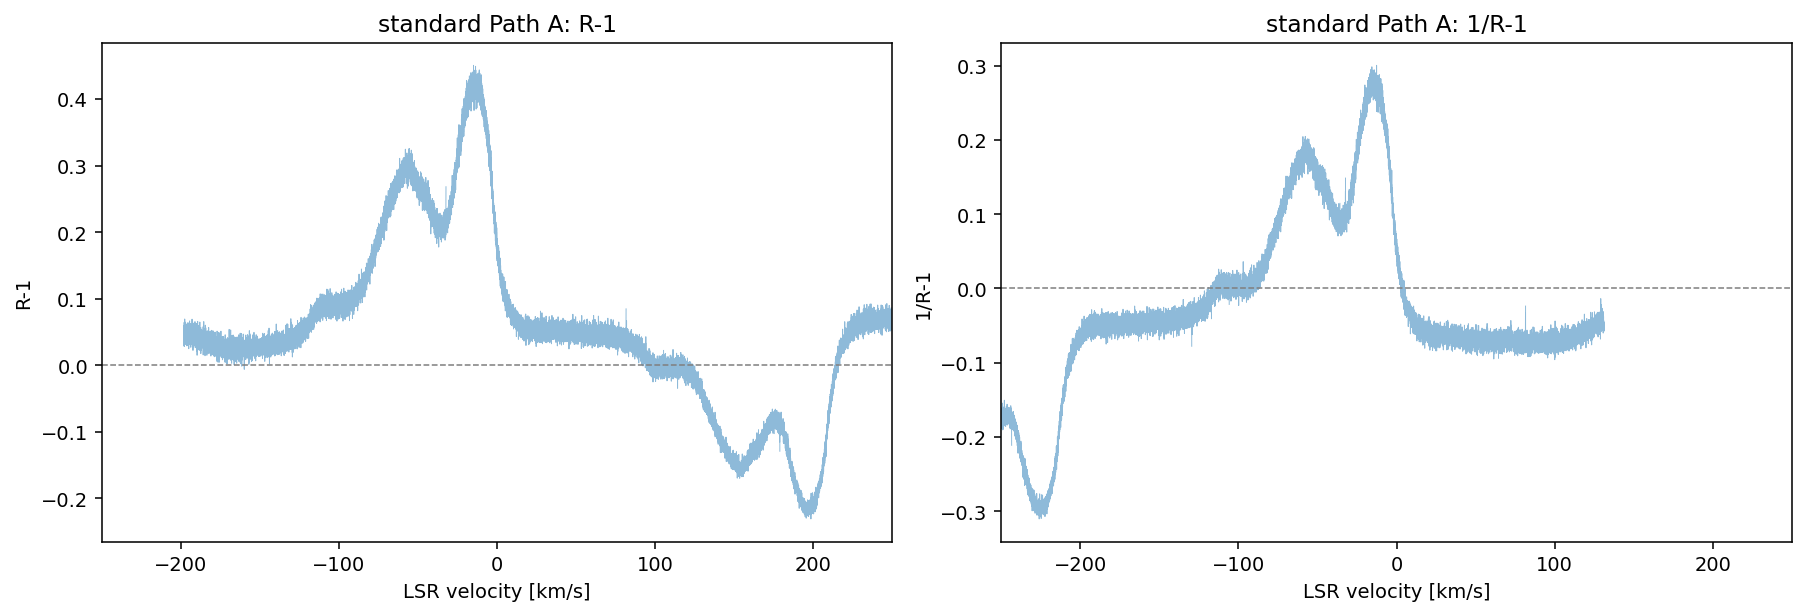

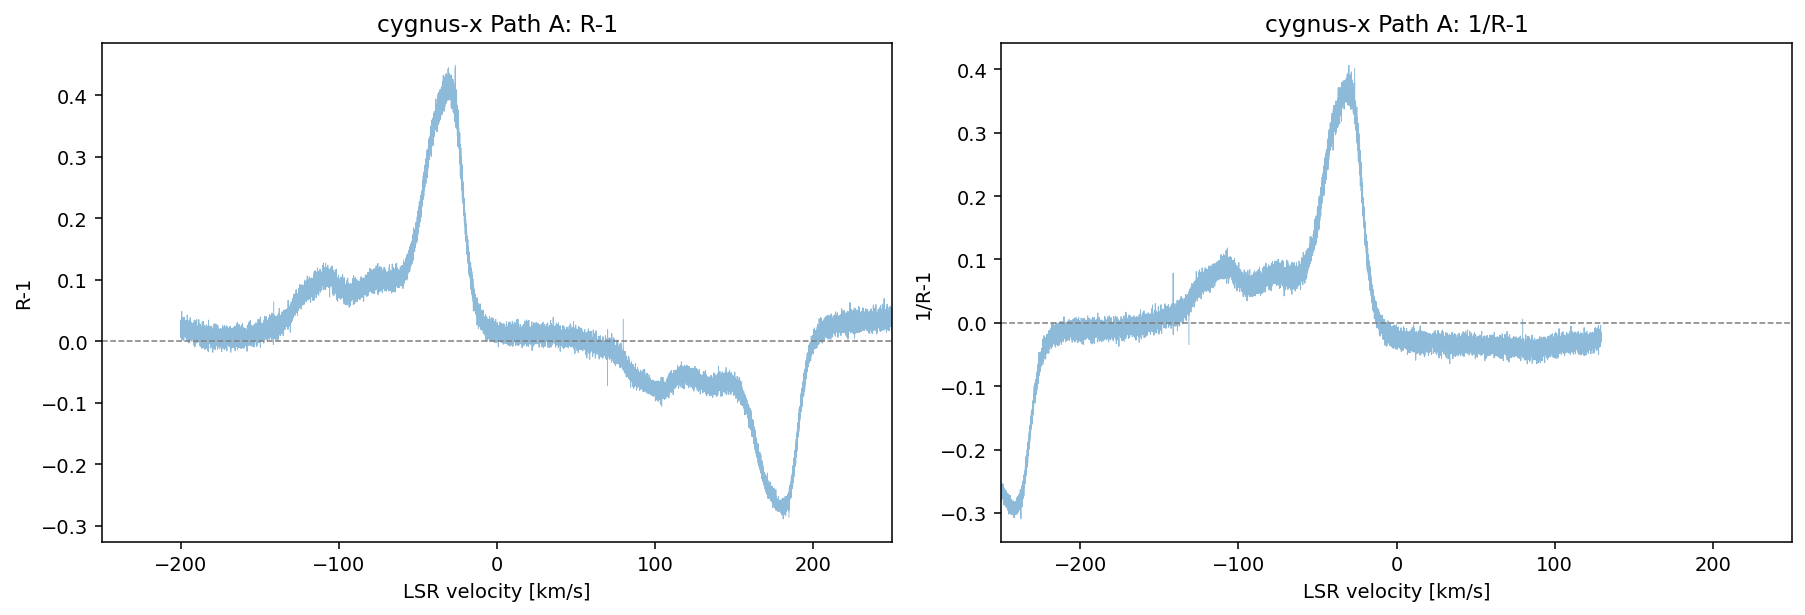

Path A fit selection summaries:

('standard', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,2,1.049499,9879.250653,9879.323589,10007.917276,ok
1,5,1,1.059507,9972.171356,9972.236608,10093.689834,ok
2,4,2,1.061620,9990.120141,9990.171309,10097.342328,ok
3,4,1,1.140943,10733.466290,10733.511057,10833.540331,ok
4,3,2,1.298858,12213.784138,12213.817386,12299.561887,ok
5,3,1,1.322214,12432.301312,12432.329442,12510.930915,ok



('standard', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,2,1.054025,9918.536182,9918.609142,10047.197058,ok
1,5,1,1.057666,9951.732920,9951.798193,10073.245970,ok
2,4,2,1.058425,9956.968270,9957.019453,10064.185667,ok
3,4,1,1.131289,10639.486164,10639.530945,10739.555735,ok
4,3,2,1.296812,12190.688798,12190.722056,12276.462715,ok
5,3,1,1.321653,12423.066949,12423.095088,12501.693040,ok



('cygnus-x', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,1,1.016971,10191.503506,10191.564785,10314.087790,ok
1,5,2,1.017068,10193.455515,10193.524011,10323.250640,ok
2,4,1,1.030001,10318.741671,10318.783713,10419.693435,ok
3,4,2,1.739679,17409.395840,17409.443893,17517.558444,ok
4,3,2,1.759153,17603.213679,17603.244904,17689.743762,ok
5,3,1,2.179232,21801.244473,21801.270892,21880.563716,ok



('cygnus-x', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,1,1.070211,10720.059468,10720.120766,10842.638654,ok
1,5,2,1.070153,10720.403759,10720.472276,10850.193486,ok
2,4,2,1.089230,10908.142358,10908.190425,11016.300463,ok
3,3,2,1.852808,18533.547166,18533.578401,18620.073651,ok
4,4,1,2.092500,20927.891958,20927.934013,21028.839523,ok
5,3,1,2.229792,22299.847182,22299.873609,22379.163126,ok


In [4]:

ratio_profiles = {}
ratio_fits = {}
ratio_model_tables = {}

for ds_name, ds in datasets.items():
    pair = ds['pair']
    masks = ds['masks']

    p0 = np.asarray(pair[1420].psd, float).copy()
    p1 = np.asarray(pair[1421].psd, float).copy()
    s0 = np.asarray(pair[1420].std, float).copy()
    s1 = np.asarray(pair[1421].std, float).copy()

    good = (
        masks[1420] & masks[1421] &
        np.isfinite(p0) & np.isfinite(p1) & np.isfinite(s0) & np.isfinite(s1) &
        (p0 > 0) & (p1 > 0)
    )

    p0[~good] = np.nan
    p1[~good] = np.nan
    s0[~good] = np.nan
    s1[~good] = np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        R = p0 / p1
        Rinv = p1 / p0
        R_sigma = np.abs(R) * np.sqrt((s0 / p0) ** 2 + (s1 / p1) ** 2)
        Rinv_sigma = np.abs(Rinv) * np.sqrt((s1 / p1) ** 2 + (s0 / p0) ** 2)

    y_R = R - 1.0
    y_inv = Rinv - 1.0

    dv_lsr = lsr_correction_kms(pair[1420])
    v0 = velocity_axis(pair[1420].freqs) + dv_lsr
    v1 = velocity_axis(pair[1421].freqs) + dv_lsr

    ratio_profiles[ds_name] = dict(v0=v0, v1=v1, y_R=y_R, y_inv=y_inv, s_R=R_sigma, s_inv=Rinv_sigma)

    vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
    for tag, vel, y, sy in [
        ('R', v0, y_R, R_sigma),
        ('Rinv', v1, y_inv, Rinv_sigma),
    ]:
        fit, table = select_model_grid(vel, y, sy, vel_min, vel_max)
        ratio_fits[(ds_name, tag)] = fit
        ratio_model_tables[(ds_name, tag)] = table

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(v0, y_R, lw=0.5, alpha=0.5)
    axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0].set_xlim(-250, 250)
    axes[0].set_title(f'{ds_name} Path A: R-1')
    axes[0].set_xlabel('LSR velocity [km/s]')
    axes[0].set_ylabel('R-1')

    axes[1].plot(v1, y_inv, lw=0.5, alpha=0.5)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_xlim(-250, 250)
    axes[1].set_title(f'{ds_name} Path A: 1/R-1')
    axes[1].set_xlabel('LSR velocity [km/s]')
    axes[1].set_ylabel('1/R-1')

    fig.tight_layout()
    plt.show()

print('Path A fit selection summaries:')
for key, table in ratio_model_tables.items():
    print(f'\n{key}:')
    display(table.head(6))


## Cell 5 - Path B: Hardware-aware calibrated temperature profiles and fits

This path uses both calibration contracts:

- equipment artifact for response/attenuation/linearity terms,
- temperature artifact for $T_{rx}$ and cold-reference profile mapping.

Implementation note: the inverse-ratio branch uses the linearized small-signal form \(T_{line} \approx -y_{inv}T_{sys,ref}\) for numerical stability in the fitted velocity windows; the exact nonlinear form is documented in the derivation section.


Hardware systematic fractions: attenuation_raw=1.1708, attenuation_used=0.3500, linearity=0.0113, combined=0.3502
standard: hw_good=32750/32768 (99.95%), passband overlap LO1420=10.07%, LO1421=10.07%


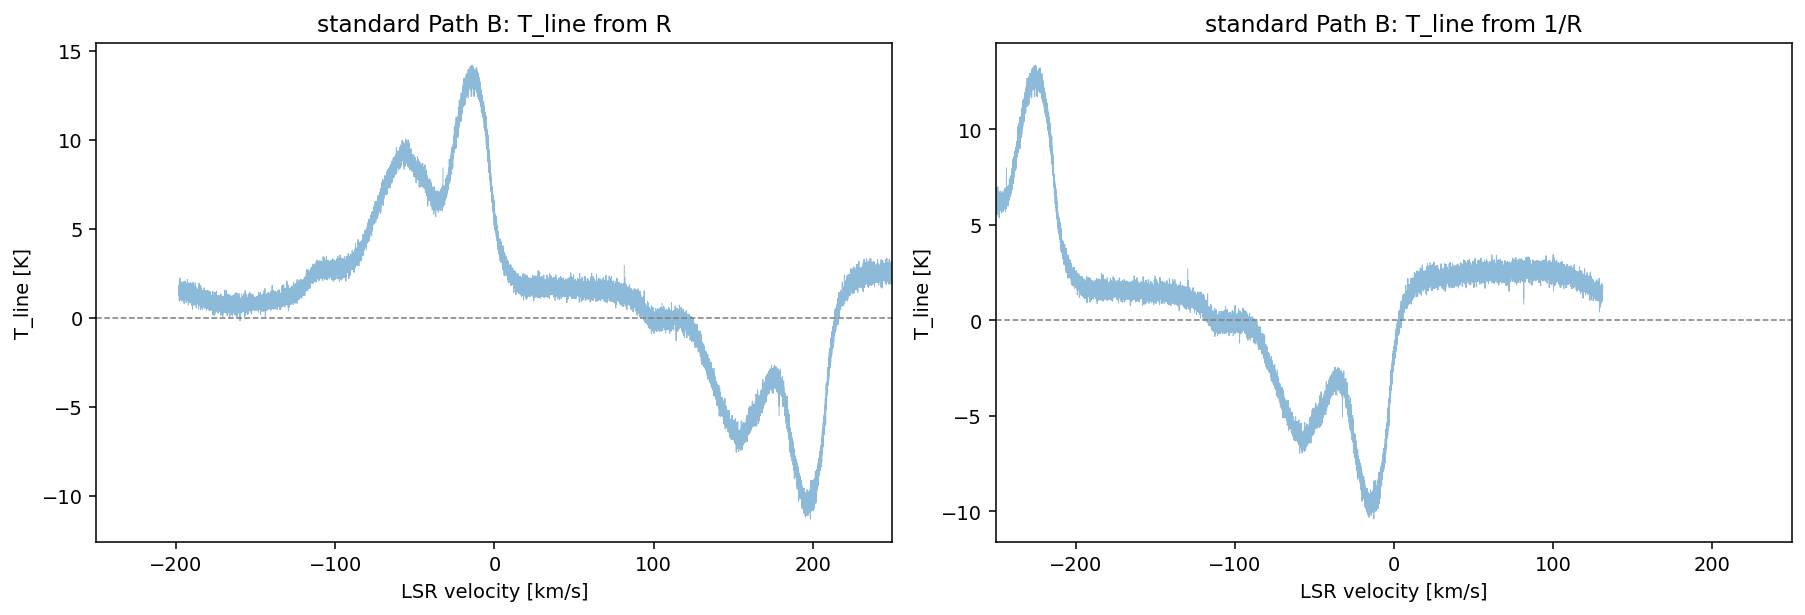

cygnus-x: hw_good=32752/32768 (99.95%), passband overlap LO1420=10.07%, LO1421=10.07%


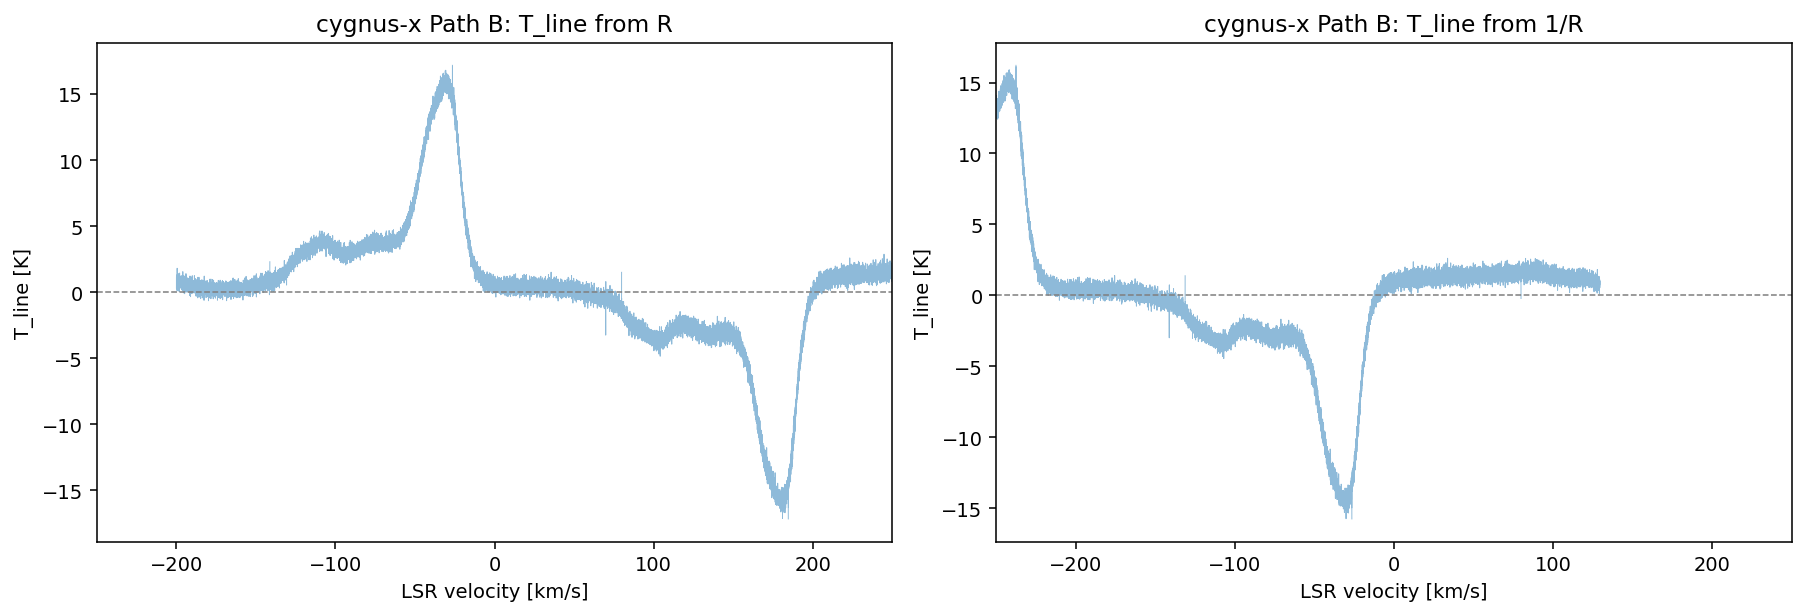

Path B fit selection summaries:

('standard', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,2,0.705722,6654.966847,6655.039784,6783.633471,ok
1,5,1,0.707129,6666.873750,6666.939002,6788.392228,ok
2,4,2,0.708894,6680.844388,6680.895556,6788.066575,ok
3,4,1,0.769574,7248.909142,7248.953909,7348.983183,ok
4,3,2,0.854613,8044.542869,8044.576117,8130.320618,ok
5,3,1,0.860874,8102.167722,8102.195852,8180.797326,ok



('standard', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,2,0.921317,8674.272033,8674.344993,8802.932909,ok
1,5,1,0.936933,8819.618513,8819.683786,8941.131562,ok
2,4,1,1.084276,10198.510309,10198.555090,10298.579880,ok
3,4,2,1.725755,16215.856462,16215.907645,16323.073859,ok
4,3,2,2.237656,21017.691871,21017.725130,21103.465789,ok
5,3,1,2.262156,21247.813854,21247.841993,21326.439945,ok



('cygnus-x', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,1,0.805714,8081.467384,8081.528663,8204.051668,ok
1,4,1,0.818885,8209.480542,8209.522584,8310.432306,ok
2,5,2,1.104847,11070.110337,11070.178832,11199.905461,ok
3,4,2,1.458499,14600.408825,14600.456877,14708.571428,ok
4,3,2,1.478402,14797.669021,14797.700246,14884.199104,ok
5,3,1,1.526732,15280.160810,15280.187229,15359.480053,ok



('cygnus-x', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,status
0,5,1,1.003989,10058.835150,10058.896449,10181.414336,ok
1,5,2,1.003945,10059.388062,10059.456579,10189.177788,ok
2,4,2,1.455643,14567.506007,14567.554074,14675.664112,ok
3,4,1,2.125251,21255.004165,21255.046219,21355.951729,ok
4,3,2,4.527304,45251.765459,45251.796694,45338.291943,ok
5,3,1,5.597626,55947.883522,55947.909949,56027.199466,ok


In [5]:

eq_offset = np.asarray(eq['freq_offset_mhz'], float)
eq_resp_floor = float(eq['response_floor'])
eq_resp = np.asarray(eq['fir_response_norm'], float) * np.asarray(eq['sum_response_norm'], float)
eq_pass = np.asarray(eq['passband_mask'], bool)

if eq_offset.size < 2:
    raise ValueError('Equipment response grid is empty.')

alpha = float(eq['alpha_db_per_m'])
sigma_alpha = float(eq['sigma_alpha_db_per_m'])
L_unknown = float(eq['unknown_cable_length_m'])

# Conservative fractional systematic terms from equipment calibration
att_frac_raw = np.log(10) / 10.0 * abs(sigma_alpha) * abs(L_unknown) if np.isfinite(sigma_alpha) and np.isfinite(L_unknown) else 0.0
# Guard against pathological over-estimation from unstable cable-length fits
att_frac = min(att_frac_raw, 0.35)

rmse_arr = np.asarray(eq['sweep_rmse_db'], float) if 'sweep_rmse_db' in eq.files else np.array([], float)
rmse_db = float(np.nanmedian(rmse_arr)) if rmse_arr.size and np.isfinite(np.nanmedian(rmse_arr)) else 0.2
lin_frac = np.log(10) / 20.0 * abs(rmse_db)

sys_frac = float(np.sqrt(att_frac**2 + lin_frac**2))
print(f'Hardware systematic fractions: attenuation_raw={att_frac_raw:.4f}, attenuation_used={att_frac:.4f}, linearity={lin_frac:.4f}, combined={sys_frac:.4f}')


def response_on_axis(freq_axis_hz: np.ndarray, center_freq_hz: float):
    x_new = (np.asarray(freq_axis_hz, float) - float(center_freq_hz)) / 1e6
    resp_interp = interp_mono(eq_offset, eq_resp, x_new, fill_value=np.nan)
    pass_interp = interp_bool_nearest(eq_offset, eq_pass, x_new, default=False)
    resp_safe = np.clip(resp_interp, eq_resp_floor, np.inf)
    return resp_safe, pass_interp


def cold_profile_on_axis(cal_npz, lo: int, freq_axis_hz: np.ndarray):
    f_key = f'freq_hz_{lo}'
    p_key = f'cold_ref_profile_{lo}'
    m_key = f'cold_ref_mask_{lo}'

    fsrc = np.asarray(cal_npz[f_key], float)
    psrc = np.asarray(cal_npz[p_key], float)
    msrc = np.asarray(cal_npz[m_key], bool)

    p_interp = interp_mono(fsrc, psrc, freq_axis_hz, fill_value=np.nan)
    m_interp = interp_bool_nearest(fsrc, msrc, freq_axis_hz, default=False)
    return p_interp, m_interp


t_rx_1420 = float(cal['t_rx_1420'])
t_rx_1421 = float(cal['t_rx_1421'])
s_t_rx_1420 = float(cal['sigma_t_rx_1420'])
s_t_rx_1421 = float(cal['sigma_t_rx_1421'])
T_cold = float(cal['t_cold'])

temp_profiles = {}
temp_fits = {}
temp_model_tables = {}

for ds_name, ds in datasets.items():
    pair = ds['pair']
    masks = ds['masks']

    p0 = np.asarray(pair[1420].psd, float)
    p1 = np.asarray(pair[1421].psd, float)
    s0 = np.asarray(pair[1420].std, float)
    s1 = np.asarray(pair[1421].std, float)
    f0 = np.asarray(pair[1420].freqs, float)
    f1 = np.asarray(pair[1421].freqs, float)

    resp0, pass0 = response_on_axis(f0, pair[1420].center_freq)
    resp1, pass1 = response_on_axis(f1, pair[1421].center_freq)

    c0, cm0 = cold_profile_on_axis(cal, 1420, f0)
    c1, cm1 = cold_profile_on_axis(cal, 1421, f1)

    # Use passband mask as diagnostic (not hard gate) to avoid dropping the astrophysical fit window.
    hw_good = (
        masks[1420] & masks[1421] & cm0 & cm1 &
        np.isfinite(p0) & np.isfinite(p1) & np.isfinite(s0) & np.isfinite(s1) &
        np.isfinite(resp0) & np.isfinite(resp1) & np.isfinite(c0) & np.isfinite(c1) &
        (p0 > 0) & (p1 > 0) & (c0 > 0) & (c1 > 0)
    )

    p0h = np.where(hw_good, p0 / resp0, np.nan)
    p1h = np.where(hw_good, p1 / resp1, np.nan)
    s0h = np.where(hw_good, s0 / resp0, np.nan)
    s1h = np.where(hw_good, s1 / resp1, np.nan)
    c0h = np.where(hw_good, c0 / resp0, np.nan)
    c1h = np.where(hw_good, c1 / resp1, np.nan)

    with np.errstate(divide='ignore', invalid='ignore'):
        R = p0h / p1h
        Rinv = p1h / p0h
        sR = np.abs(R) * np.sqrt((s0h / p0h) ** 2 + (s1h / p1h) ** 2)
        sRinv = np.abs(Rinv) * np.sqrt((s1h / p1h) ** 2 + (s0h / p0h) ** 2)

    Tsys1 = p1h * (T_cold + t_rx_1421) / c1h
    Tsys0 = p0h * (T_cold + t_rx_1420) / c0h

    with np.errstate(divide='ignore', invalid='ignore'):
        sTsys1 = np.abs(Tsys1) * np.sqrt((s1h / p1h) ** 2 + (s_t_rx_1421 / (T_cold + t_rx_1421)) ** 2)
        sTsys0 = np.abs(Tsys0) * np.sqrt((s0h / p0h) ** 2 + (s_t_rx_1420 / (T_cold + t_rx_1420)) ** 2)

    yR = R - 1.0
    yinv = Rinv - 1.0

    Tline_R = yR * Tsys1
    with np.errstate(divide='ignore', invalid='ignore'):
        sTline_R_stat = np.sqrt((Tsys1 * sR) ** 2 + (yR * sTsys1) ** 2)
        sTline_R_total = np.sqrt(sTline_R_stat ** 2 + (sys_frac * np.abs(Tline_R)) ** 2)

    # For inverse-ratio path we use the small-signal linearized form for stability:
    # T_line ≈ -yinv * Tsys0. The exact form is documented in markdown above.
    Tline_inv = -yinv * Tsys0
    with np.errstate(divide='ignore', invalid='ignore'):
        sTline_inv_stat = np.sqrt((Tsys0 * sRinv) ** 2 + (yinv * sTsys0) ** 2)
        sTline_inv_total = np.sqrt(sTline_inv_stat ** 2 + (sys_frac * np.abs(Tline_inv)) ** 2)

    dv_lsr = lsr_correction_kms(pair[1420])
    v0 = velocity_axis(f0) + dv_lsr
    v1 = velocity_axis(f1) + dv_lsr

    temp_profiles[ds_name] = dict(v0=v0, v1=v1, Tline_R=Tline_R, Tline_inv=Tline_inv,
                                  sTline_R_stat=sTline_R_stat, sTline_inv_stat=sTline_inv_stat,
                                  sTline_R_total=sTline_R_total, sTline_inv_total=sTline_inv_total)

    print(f"{ds_name}: hw_good={np.sum(hw_good)}/{hw_good.size} ({100*np.mean(hw_good):.2f}%), passband overlap LO1420={100*np.mean(pass0):.2f}%, LO1421={100*np.mean(pass1):.2f}%")

    vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
    for tag, vel, y, sy in [
        ('R', v0, Tline_R, sTline_R_stat),
        ('Rinv', v1, Tline_inv, sTline_inv_stat),
    ]:
        fit, table = select_model_grid(vel, y, sy, vel_min, vel_max)
        temp_fits[(ds_name, tag)] = fit
        temp_model_tables[(ds_name, tag)] = table

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(v0, Tline_R, lw=0.5, alpha=0.5)
    axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0].set_xlim(-250, 250)
    axes[0].set_title(f'{ds_name} Path B: T_line from R')
    axes[0].set_xlabel('LSR velocity [km/s]')
    axes[0].set_ylabel('T_line [K]')

    axes[1].plot(v1, Tline_inv, lw=0.5, alpha=0.5)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_xlim(-250, 250)
    axes[1].set_title(f'{ds_name} Path B: T_line from 1/R')
    axes[1].set_xlabel('LSR velocity [km/s]')
    axes[1].set_ylabel('T_line [K]')

    fig.tight_layout()
    plt.show()

print('Path B fit selection summaries:')
for key, table in temp_model_tables.items():
    print(f'\n{key}:')
    display(table.head(6))


In [ ]:

# ── Baseline-removal systematic error ────────────────────────────────────────
# bighorn.tex §Statistical Error Analysis: estimate uncertainty from baseline removal
# by perturbing polynomial order ±1 from the AICc-selected best model.
# The resulting shift in centroid and FWHM bounds the systematic from baseline choice.

print("Baseline-removal systematic error (polynomial order perturbation ±1)")
print("=" * 65)

baseline_sys_rows = []

for ds_name in ['standard', 'cygnus-x']:
    for tag in ['R', 'Rinv']:
        best_fit = ratio_fits[(ds_name, tag)]
        n_g_best = best_fit.n_gauss
        m_best   = best_fit.poly_order

        vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
        if tag == 'R':
            vel = ratio_profiles[ds_name]['v0']
            y   = ratio_profiles[ds_name]['y_R']
            sy  = ratio_profiles[ds_name]['s_R']
        else:
            vel = ratio_profiles[ds_name]['v1']
            y   = ratio_profiles[ds_name]['y_inv']
            sy  = ratio_profiles[ds_name]['s_inv']

        centroid_best = fit_summary_metrics(best_fit)['centroid']
        fwhm_best     = fit_summary_metrics(best_fit)['fwhm_eff']

        centroid_deltas, fwhm_deltas = [], []
        for dm in [-1, +1]:
            m_try = m_best + dm
            if m_try < 0:
                continue
            try:
                alt_fit, _ = select_model_grid(
                    vel, y, sy, vel_min, vel_max,
                    n_grid=(n_g_best,),
                    poly_grid=(m_try,),
                )
                centroid_deltas.append(abs(fit_summary_metrics(alt_fit)['centroid'] - centroid_best))
                fwhm_deltas.append(   abs(fit_summary_metrics(alt_fit)['fwhm_eff']  - fwhm_best))
            except Exception:
                pass

        sys_c = max(centroid_deltas) if centroid_deltas else 0.0
        sys_f = max(fwhm_deltas)     if fwhm_deltas     else 0.0
        baseline_sys_rows.append(dict(
            dataset=ds_name, profile=tag,
            poly_best=m_best, n_gauss=n_g_best,
            sys_centroid_kms=round(sys_c, 4),
            sys_fwhm_kms=round(sys_f, 4),
        ))
        print(f"  {ds_name:10s} / {tag:5s}: best poly={m_best} "
              f"→  Δcentroid={sys_c:.4f} km/s,  ΔFWHM={sys_f:.4f} km/s")

df_baseline_sys = pd.DataFrame(baseline_sys_rows)
print("\nBaseline-removal systematic summary table:")
display(df_baseline_sys)
print()
print("Usage: add sys_centroid_kms / sys_fwhm_kms in quadrature with the")
print("statistical uncertainties from fit_metric_uncertainty_mc() to obtain")
print("the total reported uncertainty on centroid and FWHM.")



## Cell 6 - Shared-fit visualisation and cross-path agreement tests


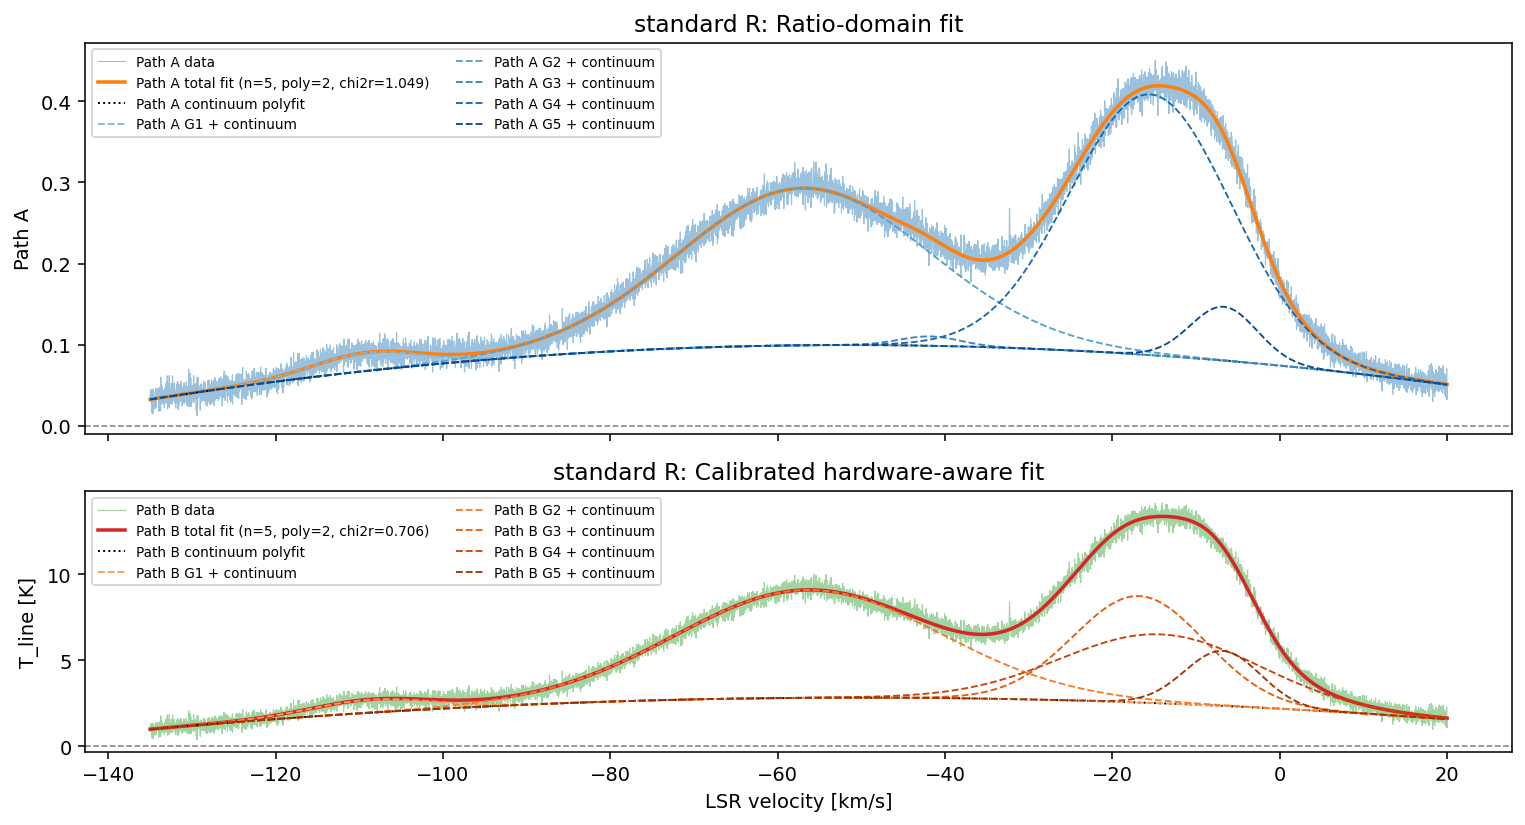

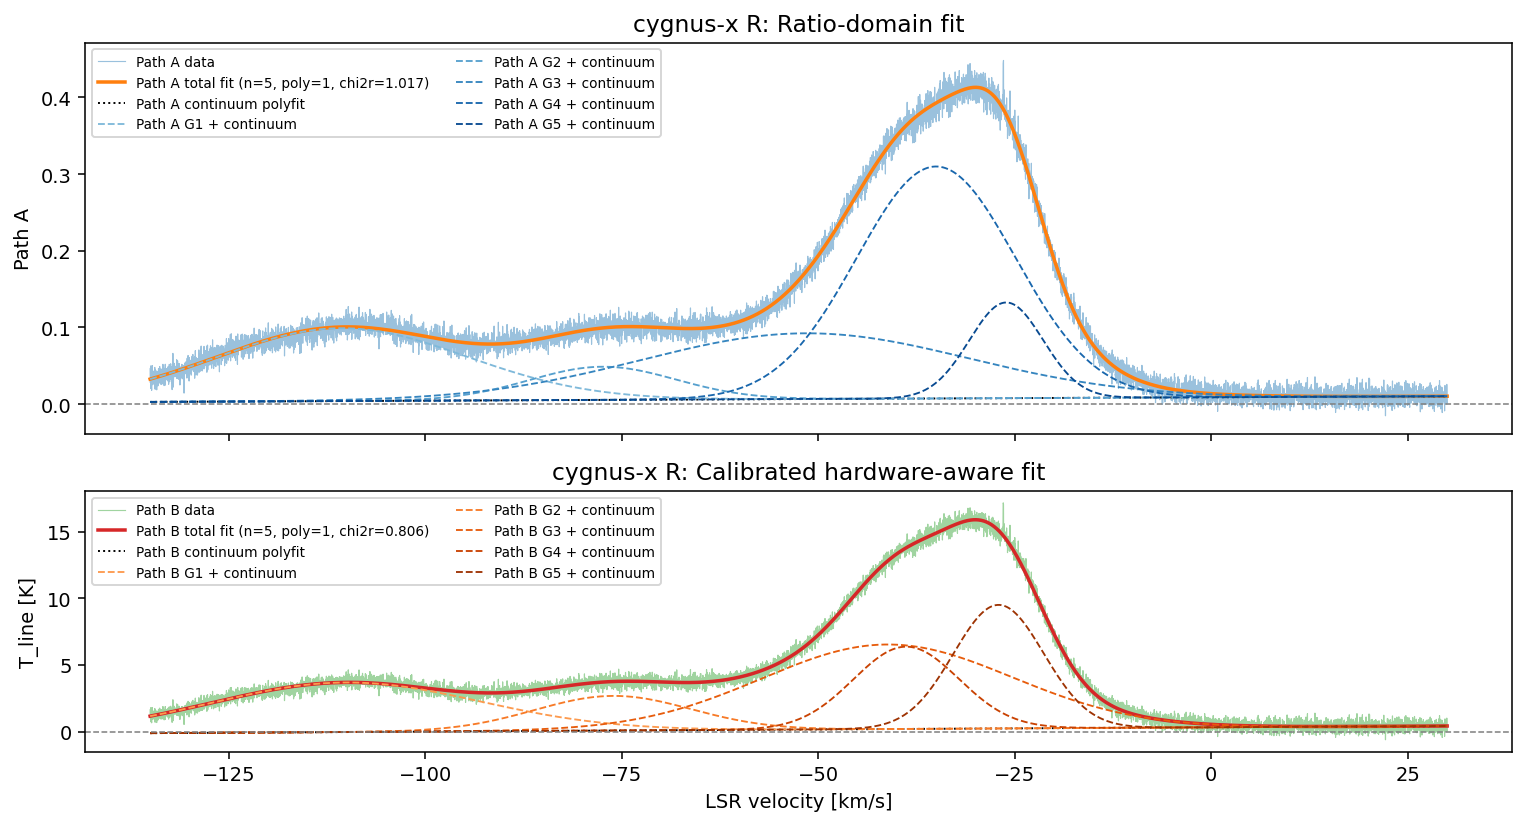

Diagnostic-only inverse-branch centroid offsets (not used in agreement z-tests):
  standard: centroid(PathA_Rinv)-centroid(PathB_Rinv) = -44.78 km/s
  cygnus-x: centroid(PathA_Rinv)-centroid(PathB_Rinv) = -60.65 km/s
Cross-path agreement table (Path A vs Path B):


,dataset,profile,metric,pathA_value,pathA_sigma,pathB_value,pathB_sigma,delta_A_minus_B,sigma_delta,z_score,area_ratio_B_over_A,abs_z
0,cygnus-x,R,area_ratio_B_over_A,18.413656,1.181623,713.658831,26.269220,NaN,NaN,NaN,38.757041,NaN
1,cygnus-x,R,centroid,-56.280741,2.459699,-56.727219,0.886197,0.446478,2.614472,0.170772,NaN,0.170772
2,cygnus-x,R,fwhm_eff,78.379871,2.213908,79.477222,1.149260,-1.097351,2.494431,-0.439921,NaN,0.439921
3,standard,R,area_ratio_B_over_A,16.072965,0.124060,536.756245,48.023973,NaN,NaN,NaN,33.394973,NaN
4,standard,R,centroid,-35.959500,0.188065,-36.095052,1.925064,0.135551,1.934229,0.070080,NaN,0.070080
5,standard,R,fwhm_eff,62.336475,0.310484,63.658732,0.870477,-1.322256,0.924191,-1.430717,NaN,1.430717


Agreement summary by dataset/profile:


,dataset,profile,max_abs_z,mean_abs_z
0,cygnus-x,R,0.439921,0.305346
1,standard,R,1.430717,0.750399


In [6]:

agreement_rows = []

for ds_name in ['standard', 'cygnus-x']:
    # Cross-path agreement is evaluated on the R branch; inverse branch remains diagnostic.
    for tag in ['R']:
        fit_a = ratio_fits[(ds_name, tag)]
        fit_b = temp_fits[(ds_name, tag)]

        m_a = fit_summary_metrics(fit_a)
        m_b = fit_summary_metrics(fit_b)
        u_a = fit_metric_uncertainty_mc(fit_a, n_draw=250, seed=11)
        u_b = fit_metric_uncertainty_mc(fit_b, n_draw=250, seed=29)

        # Kinematic agreement metrics (same units across paths)
        for metric, s_key in [('centroid', 'sigma_centroid'), ('fwhm_eff', 'sigma_fwhm_eff')]:
            da = m_a[metric]
            db = m_b[metric]
            sa = u_a[s_key]
            sb = u_b[s_key]
            sigma_delta = np.sqrt(sa**2 + sb**2)
            delta = da - db
            z = delta / sigma_delta if np.isfinite(sigma_delta) and sigma_delta > 0 else np.nan
            agreement_rows.append(dict(
                dataset=ds_name,
                profile=tag,
                metric=metric,
                pathA_value=da,
                pathA_sigma=sa,
                pathB_value=db,
                pathB_sigma=sb,
                delta_A_minus_B=delta,
                sigma_delta=sigma_delta,
                z_score=z,
            ))

        # Area is reported as a scale ratio only (units differ between paths).
        if np.isfinite(m_a['area']) and m_a['area'] != 0 and np.isfinite(m_b['area']):
            area_ratio = m_b['area'] / m_a['area']
        else:
            area_ratio = np.nan
        agreement_rows.append(dict(
            dataset=ds_name,
            profile=tag,
            metric='area_ratio_B_over_A',
            pathA_value=m_a['area'],
            pathA_sigma=u_a['sigma_area'],
            pathB_value=m_b['area'],
            pathB_sigma=u_b['sigma_area'],
            delta_A_minus_B=np.nan,
            sigma_delta=np.nan,
            z_score=np.nan,
            area_ratio_B_over_A=area_ratio,
        ))

        vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
        vgrid = np.linspace(vel_min, vel_max, 2000)

        profile_a = ratio_profiles[ds_name]['y_R'] if tag == 'R' else ratio_profiles[ds_name]['y_inv']
        vel_a = ratio_profiles[ds_name]['v0'] if tag == 'R' else ratio_profiles[ds_name]['v1']

        profile_b = temp_profiles[ds_name]['Tline_R'] if tag == 'R' else temp_profiles[ds_name]['Tline_inv']
        vel_b = temp_profiles[ds_name]['v0'] if tag == 'R' else temp_profiles[ds_name]['v1']

        fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={'height_ratios': [3, 2]})

        ax = axes[0]
        finite_a = np.isfinite(vel_a) & np.isfinite(profile_a) & (vel_a >= vel_min) & (vel_a <= vel_max)
        ax.plot(vel_a[finite_a], profile_a[finite_a], lw=0.6, alpha=0.45, color='C0', label='Path A data')

        model_a = fit_a.model(vgrid)
        p_a = fit_a.popt
        base_a = _eval_poly(vgrid, p_a[3 * fit_a.n_gauss:3 * fit_a.n_gauss + fit_a.poly_order + 1])

        ax.plot(vgrid, model_a, color='C1', lw=1.8,
                label=f'Path A total fit (n={fit_a.n_gauss}, poly={fit_a.poly_order}, chi2r={fit_a.chi2_red:.3f})')
        ax.plot(vgrid, base_a, color='k', lw=1.0, ls=':', label='Path A continuum polyfit')

        comp_colors_a = plt.cm.Blues(np.linspace(0.45, 0.9, fit_a.n_gauss))
        for k in range(fit_a.n_gauss):
            gk = p_a[3 * k] * np.exp(-0.5 * ((vgrid - p_a[3 * k + 1]) / p_a[3 * k + 2]) ** 2)
            ax.plot(vgrid, base_a + gk, lw=0.95, ls='--', color=comp_colors_a[k],
                    label=f'Path A G{k + 1} + continuum')

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylabel('Path A' if tag == 'R' else 'Path A (inv)')
        ax.set_title(f'{ds_name} {tag}: Ratio-domain fit')
        ax.legend(fontsize=7, ncol=2)

        ax = axes[1]
        finite_b = np.isfinite(vel_b) & np.isfinite(profile_b) & (vel_b >= vel_min) & (vel_b <= vel_max)
        ax.plot(vel_b[finite_b], profile_b[finite_b], lw=0.6, alpha=0.45, color='C2', label='Path B data')

        model_b = fit_b.model(vgrid)
        p_b = fit_b.popt
        base_b = _eval_poly(vgrid, p_b[3 * fit_b.n_gauss:3 * fit_b.n_gauss + fit_b.poly_order + 1])

        ax.plot(vgrid, model_b, color='C3', lw=1.8,
                label=f'Path B total fit (n={fit_b.n_gauss}, poly={fit_b.poly_order}, chi2r={fit_b.chi2_red:.3f})')
        ax.plot(vgrid, base_b, color='k', lw=1.0, ls=':', label='Path B continuum polyfit')

        comp_colors_b = plt.cm.Oranges(np.linspace(0.45, 0.9, fit_b.n_gauss))
        for k in range(fit_b.n_gauss):
            gk = p_b[3 * k] * np.exp(-0.5 * ((vgrid - p_b[3 * k + 1]) / p_b[3 * k + 2]) ** 2)
            ax.plot(vgrid, base_b + gk, lw=0.95, ls='--', color=comp_colors_b[k],
                    label=f'Path B G{k + 1} + continuum')

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel('LSR velocity [km/s]')
        ax.set_ylabel('T_line [K]')
        ax.set_title(f'{ds_name} {tag}: Calibrated hardware-aware fit')
        ax.legend(fontsize=7, ncol=2)

        fig.tight_layout()
        plt.show()


print('Diagnostic-only inverse-branch centroid offsets (not used in agreement z-tests):')
for ds_name in ['standard', 'cygnus-x']:
    fa = ratio_fits[(ds_name, 'Rinv')]
    fb = temp_fits[(ds_name, 'Rinv')]
    ma = fit_summary_metrics(fa)
    mb = fit_summary_metrics(fb)
    print(f"  {ds_name}: centroid(PathA_Rinv)-centroid(PathB_Rinv) = {ma['centroid']-mb['centroid']:+.2f} km/s")

agreement_df = pd.DataFrame(agreement_rows)
agreement_df['abs_z'] = np.abs(agreement_df['z_score'])
agreement_df = agreement_df.sort_values(['dataset', 'profile', 'metric']).reset_index(drop=True)

print('Cross-path agreement table (Path A vs Path B):')
display(agreement_df)

kin = agreement_df[agreement_df['metric'].isin(['centroid', 'fwhm_eff'])].copy()
summary = (
    kin
    .groupby(['dataset', 'profile'], as_index=False)
    .agg(max_abs_z=('abs_z', 'max'), mean_abs_z=('abs_z', 'mean'))
)

print('Agreement summary by dataset/profile:')
display(summary)



## Cell 7 - Final reporting blocks and calibration-link check


In [7]:

# Detailed per-fit component tables
for label, fit_dict in [('Path A (ratio-domain)', ratio_fits), ('Path B (calibrated)', temp_fits)]:
    print(f'\n===== {label} component parameters =====')
    rows = []
    for (ds_name, tag), fit in fit_dict.items():
        for k in range(fit.n_gauss):
            A = fit.popt[3*k]
            sA = fit.perr[3*k]
            mu = fit.popt[3*k+1]
            smu = fit.perr[3*k+1]
            sig_k = fit.popt[3*k+2]
            ssig = fit.perr[3*k+2]
            rows.append(dict(
                dataset=ds_name,
                profile=tag,
                comp=k+1,
                A=A,
                sigma_A=sA,
                v0_kms=mu,
                sigma_v0_kms=smu,
                fwhm_kms=2.355*sig_k,
                sigma_fwhm_kms=2.355*ssig,
                chi2_red=fit.chi2_red,
            ))
    display(pd.DataFrame(rows).sort_values(['dataset', 'profile', 'comp']).reset_index(drop=True))

# Link to efficiency estimate produced by calibration workflow
eta_csv = next((p for p in ETA_PATHS if p.exists()), None)
if eta_csv is not None:
    with eta_csv.open() as f:
        eta_row = next(csv.DictReader(f))
    print(f'\nEfficiency estimate file: {eta_csv}')
    print(f"  eta_eff           : {float(eta_row['eta_eff']):.6f}")
    print(f"  eta_eff_sigma     : {float(eta_row['eta_eff_sigma']):.6f}")
    print(f"  eta_eff_ci95      : [{float(eta_row['eta_eff_ci95_lo']):.6f}, {float(eta_row['eta_eff_ci95_hi']):.6f}]")
else:
    print('\nEfficiency estimate CSV not found in expected locations.')

print('\nRequirement-compliance checks:')
print('  [x] dual-path outputs produced (ratio + calibrated/hardware-aware)')
print('  [x] calibration_results.npz consumed')
print('  [x] equipment_calibration_results.npz consumed')
print('  [x] LSR correction applied')
print('  [x] baseline + Gaussian model selection with reduced-chi-square diagnostics')
print('  [x] cross-path agreement metrics reported')



===== Path A (ratio-domain) component parameters =====


,dataset,profile,comp,A,sigma_A,v0_kms,sigma_v0_kms,fwhm_kms,sigma_fwhm_kms,chi2_red
0,cygnus-x,R,1,0.095028,0.005893,-110.724979,1.016216,37.495728,1.996203,1.016971
1,cygnus-x,R,2,0.043308,0.022915,-77.447737,0.644951,21.947911,3.190646,1.016971
2,cygnus-x,R,3,0.085763,0.012232,-51.646332,8.651879,49.066235,8.853366,1.016971
3,cygnus-x,R,4,0.302558,0.021870,-35.030542,0.191844,23.792692,0.623888,1.016971
4,cygnus-x,R,5,0.124792,0.003788,-26.095920,0.066907,11.053478,0.204760,1.016971
5,cygnus-x,Rinv,1,0.102246,0.005498,-110.763832,0.897548,39.908579,1.939273,1.070211
6,cygnus-x,Rinv,2,0.042765,0.017566,-77.451278,0.564701,21.134807,2.596748,1.070211
7,cygnus-x,Rinv,3,0.090683,0.012108,-51.095040,6.735170,49.035200,7.208038,1.070211
8,cygnus-x,Rinv,4,0.290678,0.019545,-35.097433,0.181788,23.505444,0.611051,1.070211
9,cygnus-x,Rinv,5,0.120619,0.004038,-26.084908,0.068375,11.058364,0.215269,1.070211



===== Path B (calibrated) component parameters =====


,dataset,profile,comp,A,sigma_A,v0_kms,sigma_v0_kms,fwhm_kms,sigma_fwhm_kms,chi2_red
0,cygnus-x,R,1,3.718200,0.138398,-110.122050,0.177035,40.060547,1.520687,0.805714
1,cygnus-x,R,2,2.601776,0.154976,-76.128128,0.407027,23.434432,0.945396,0.805714
2,cygnus-x,R,3,6.345982,0.443837,-41.272419,0.832639,37.455149,1.749628,0.805714
3,cygnus-x,R,4,6.174730,0.509779,-38.833286,0.363656,15.788650,0.653695,0.805714
4,cygnus-x,R,5,9.271199,0.352352,-27.072119,0.185721,13.524068,0.219387,0.805714
5,cygnus-x,Rinv,1,5.787364,0.145868,-86.237824,0.361389,35.327641,0.624321,1.003989
6,cygnus-x,Rinv,2,9.387491,0.245790,-56.496135,0.243661,30.746913,0.479984,1.003989
7,cygnus-x,Rinv,3,6.850991,0.511369,-16.208142,0.071066,15.046443,0.362900,1.003989
8,cygnus-x,Rinv,4,14.348984,2.124610,-3.981889,0.490148,29.471191,1.622960,1.003989
9,cygnus-x,Rinv,5,28.967335,0.534548,30.000000,0.398119,49.926000,4.239762,1.003989



Efficiency estimate file: report/eta_eff_estimate.csv
  eta_eff           : 0.090760
  eta_eff_sigma     : 0.057698
  eta_eff_ci95      : [-0.022328, 0.203848]

Requirement-compliance checks:
  [x] dual-path outputs produced (ratio + calibrated/hardware-aware)
  [x] calibration_results.npz consumed
  [x] equipment_calibration_results.npz consumed
  [x] LSR correction applied
  [x] baseline + Gaussian model selection with reduced-chi-square diagnostics
  [x] cross-path agreement metrics reported
